<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons Licence" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">Activity 1.2 - Simulating Stochastic Processes</span> by <span xmlns:cc="http://creativecommons.org/ns#" property="cc:attributionName">Marc de Kamps and University of Leeds</span> is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>.

### Preparation

- Consult the following link as an entry for random process generation: https://numpy.org/doc/stable/reference/random/index.html
- Read up on random number generators. The Wikipedia entry is a decent enough start: https://en.wikipedia.org/wiki/Random_number_generation. For an introduction to the more technical aspects, the book *Numerical Recipes in C*, by Press *et al* contains an informative chapter.

In [1]:
from numpy.random import default_rng
rng = default_rng(seed = 12)
vals = rng.uniform(size=10)
print(vals)

[0.25082446 0.94675294 0.18932038 0.17929141 0.34988924 0.23054125
 0.67044574 0.11507938 0.89630937 0.85813049]


### Numpy's random module
To generate samples according to various distributions, *numpy.random* is convenient. Above you see an example of how to generate 10 random values.

**Exercise**: note down some of the values that were printed. Now go to the top menu of the notebook, select *Kernel*
and select *Restart & Clear Output*. Run the notebook again. Comment on whether you observe the same values.
If the numbers change every time you restart the book, is this desirable? 
- Comment on situations were this is potentially valuable
    - Where we want to demonstrate that a particular model or distribution applies to any set of numbers / datapoints
    - Where we want to test how a model or distribution may change based on different inputs

There are also good reasons for this to be undesirable. 

- State at least one reason for why this is undesirable behaviour.
    - When we want to demonstrate repeatable behaviour, particularly useful when creating a report that others can try and repeat
- If this undesirable behaviour, investigate how you can use seed to prevent it.
    - A seed value ensures that the same 'random' numbers are provided (different seed values provide different 'random' sequences of numbers)

### Common Sense: looking at your data.
*Exercise*: Generate 10000 data points and histogram them in the interval $[0,1]$. The histogram should be approximately flat.

In [2]:
import matplotlib.pyplot as plt

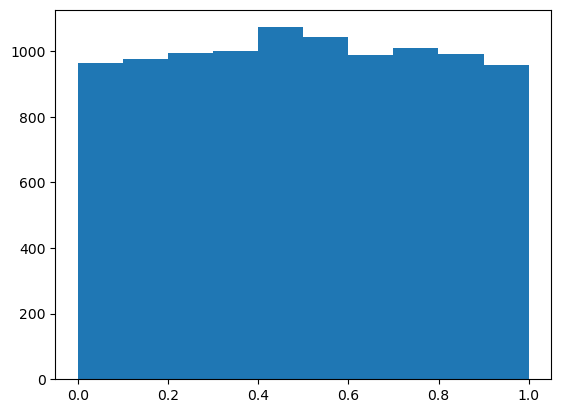

In [4]:
my_rng = default_rng(seed = 42)
vals = rng.uniform(low=0, high=1, size=10000)

plt.hist(vals)
plt.show()

**Exercise**: Generate 10000 data points $(x,y)$ that are uniformly distributed in the interval $[0,1] \times [0,1]$. Make a scatter plot of the sample and comment on whether the result is as expected.

**Comment**: Basically what was expected to be seen, with so many datapoints it is difficult to make out the individual points

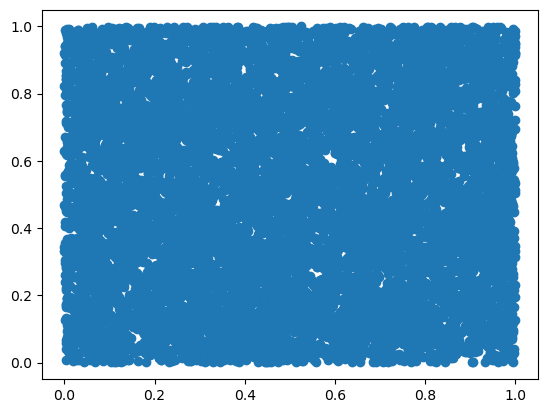

In [19]:
vals_scatter = rng.uniform(low=0, high=1, size=(2,10000))
plt.scatter(vals_scatter[0], vals_scatter[1])
plt.show()

**Exercise**: Investigate how you can change the aspect ratio of a plot in the notebook and how you can change the dpi (dots per inch). Experiment to make a plot that you find visually attractive: change marker color and type, as well as size. Save the plot as a pdf file.

In [21]:
import matplotlib as mpl

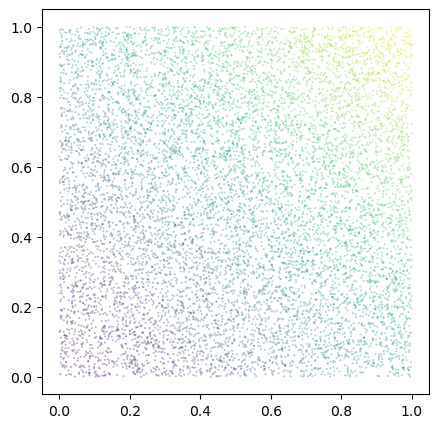

In [56]:
mpl.rcParams['figure.dpi'] = 200
marker_color = [(vals_scatter[0][i] + vals_scatter[1][i])/2 for i in range(len(vals_scatter[0]))]
plt.figure(figsize=(5,5), dpi=100)
plt.scatter(vals_scatter[0], vals_scatter[1], marker='.', s=0.5,
            alpha=0.5, c=marker_color, cmap='viridis')
plt.savefig('random_scatter_10k.pdf')
plt.show()

**Exercise:** Now that you can simulate uniformly distributed numbers, it is not hard to simulate a Bernoulli process. Simulate a sample of 1000 uniformly distributed events ($[0,1]$), think of a way of converting them into a sequence generated by a Bernoulli process with $\mu = 0.4$. Implement this in Python and perform some common sense checks to whether the result is reasonable.

In [64]:
vals_bernoulli = rng.uniform(low=0, high=1, size=1000)
mu = 0.4
results_bernoulli = [1 if x < mu else 0 for x in vals_bernoulli]
#print(results_bernoulli)
print(sum(results_bernoulli))

388


**Exercise**: Design and implement a function simulate a Bernoulli sample of arbitrary length. Use this as a basis for a function that generates binomial samples. Generate a sample of 10000 $\mbox{Bin}(N=10,p=0.25)$ events. Plot a histogram of the sample that you generated.

*Translation*: Generate a sample of 10,000 events a Bernoulli Process that has a sample size of 10 with a $\mu = 0.25$

In [70]:
import numpy as np

[[0 1 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 1 1]
 [0 0 0 1 1 1 1 0 0 0]
 [1 0 0 1 0 1 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0]
 [1 0 1 0 0 1 0 0 0 1]]


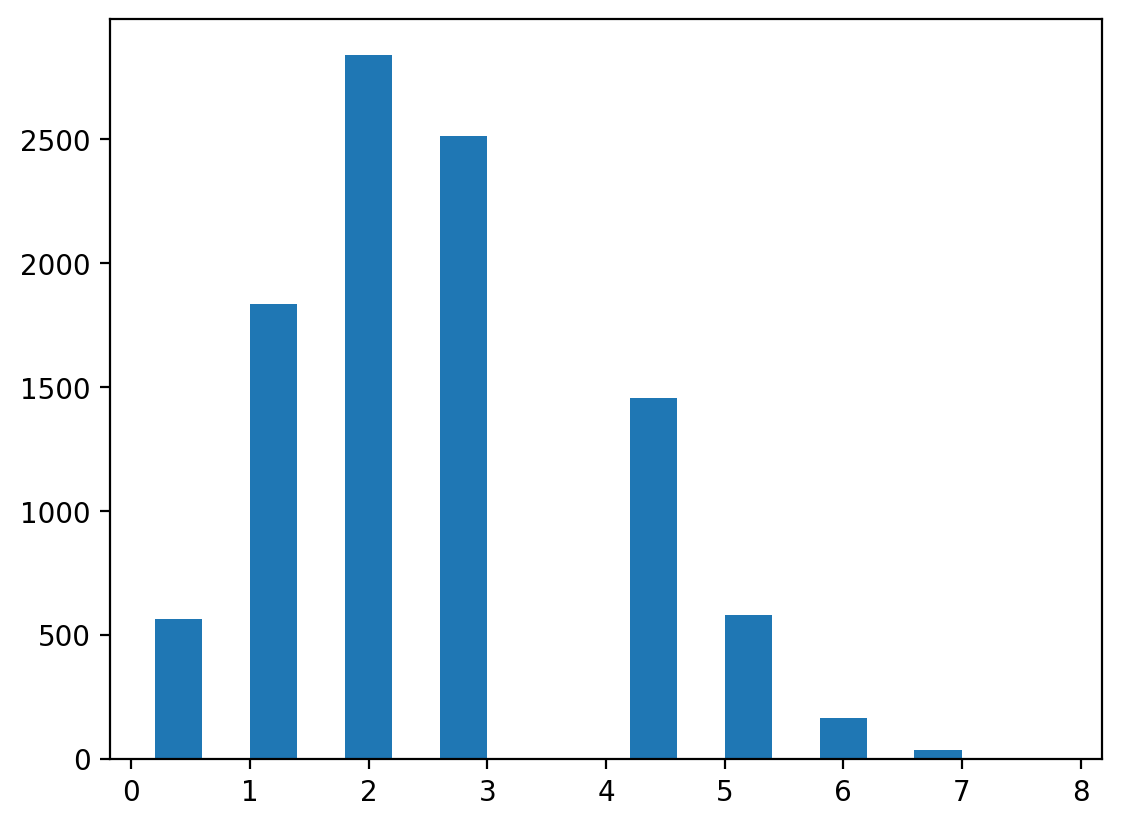

In [107]:
def bernoulli_simulator(size, mu):
    my_rng = default_rng()
    uniform_vals = my_rng.uniform(size=size)
    results = [1 if x < mu else 0 for x in uniform_vals]
    return results

def bin(n_events, bern_samples, mu):
    return [bernoulli_simulator(bern_samples, mu) for i in range(n_events)]

results = np.array(bin(10000, 10, 0.25))

print(results[:10])
sum_results = [sum(results[i]) for i in range(results.shape[0])]
plt.hist(sum_results, rwidth = 0.5)
plt.show()

**Exercise** Research the *numpy.random.binomial* method. Use the method to repeat the previous experiment. Also, research whether a method *numpy.random.bernoulli* exists. If not, explain why not.

**Answer**: The Bernoulli Distribution is a special case of the Binomial Distribution, where N=1. This means we can simply use nump.random.binomial with n=1 to create the Bernoulli Distribution

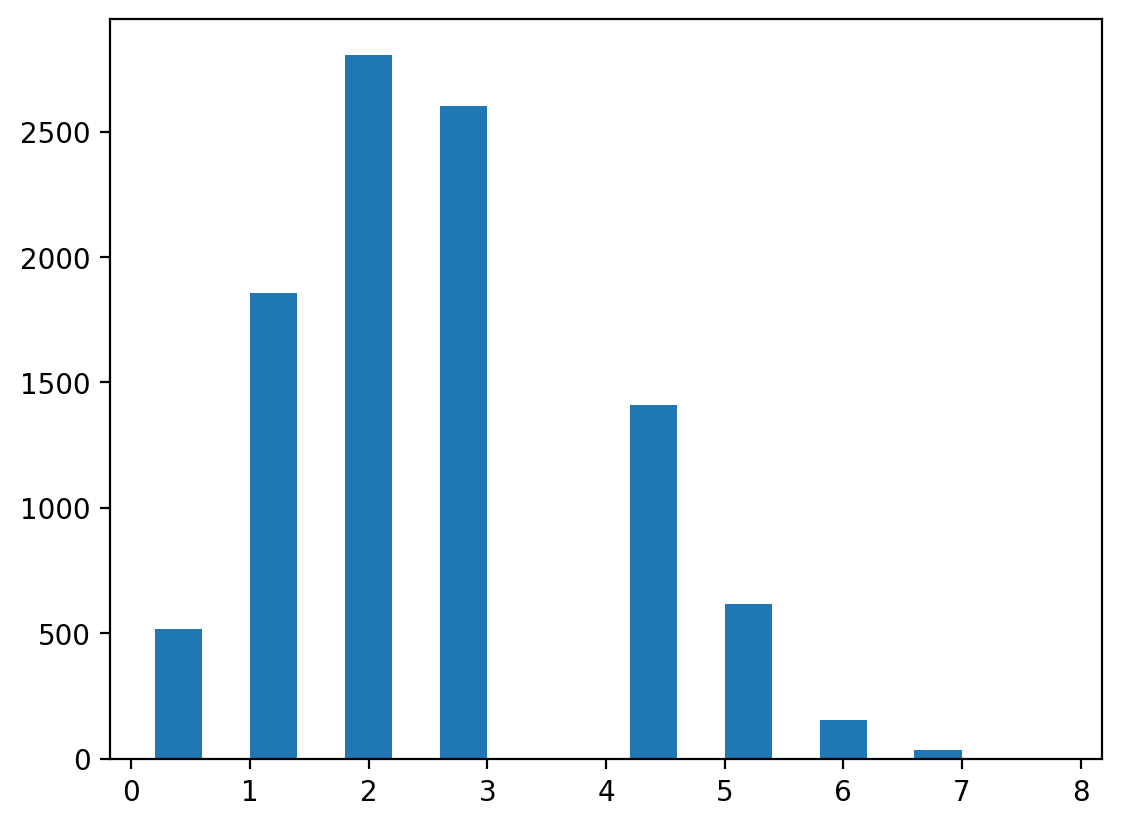

In [95]:
my_binomial = np.random.binomial(10, 0.25, 10000)

plt.hist(my_binomial, rwidth = 0.5)
plt.show()

## The Moral of the Story (so far)

The really hard bit about generating random numbers is the generation of uniformly distributed random numbers. Once this is in place, discrete stochastic processes can be modelled relatively easily, although numpy.random provides a convenient front end for most distributions. Feel free to experiment with other distributions.

## Continuous Distributions

It sounds much harder to model a continuous distribution based on a uniform sample, but it is straightforward (in one dimension). If we apply a function $f(x)$ to a uniform distribution, it is no longer uniform. Let's apply the function $f(x) = x^{2}$ to a sample of uniformly distributed events in the interval $[0,1]$. Do this and plot
a histogram of the resulting distribution. Use 50 bins for your histogram.

Also plot the function $g(x) = 100/\sqrt(x)$.



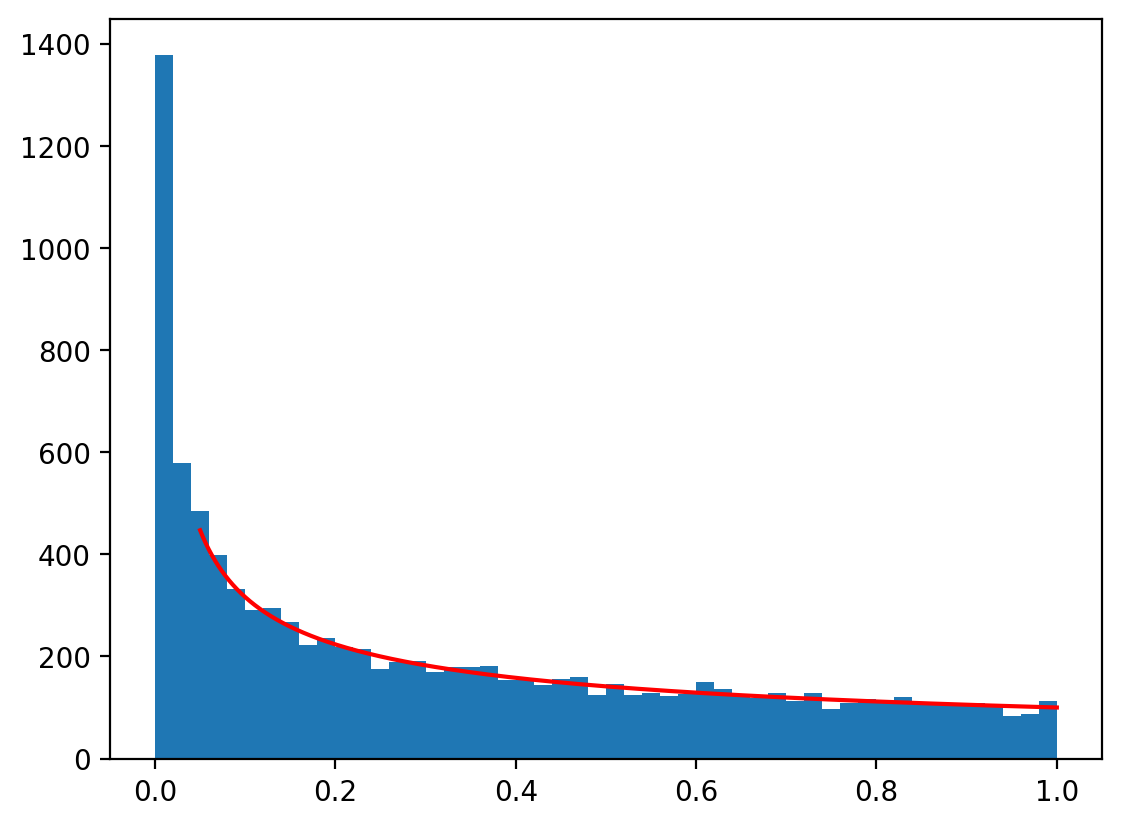

In [106]:
rng = default_rng()
uniform_values = rng.uniform(size=10000)
f = np.square(uniform_values)
plt.hist(f, bins=50)

line_x = np.linspace(0.05,1,9500)
line_y = 100/np.sqrt(line_x)
plt.plot(line_x, line_y, c='r')

plt.show()

If all went well, you have simulated samples distributed with a distribution $g(x) = 100/\sqrt(x)$. Try to reason why it worked out this way.
At the very least, try to understand why a function applied to a sample generated by the homogeneous distribution
is  no longer uniform. The moral of the story is that it is easy to sculpt distributions into a desired shape, once a good algorithm for generating uniformly distributed events is available.

*My Answer*: Squaring a small number makes it much smaller (e.g. $0.1^2$), which makes the distribution skew towards 0. When we apply this to something like a Bernoulli distribution, this means that, depending on the $\mu$, the proability of 1 being the result increases significantly

A full explanantion